## Diagrama de Gantt


*Concepción y desarrollo del proyecto (Noviembre 2025):* Incluye la definición de objetivos y la organización inicial del equipo.

*Adquisición de fuentes de datos (Noviembre - Diciembre 2025):* Fase crítica que contempla la descarga de datos de calidad del aire desde OpenAQ , estadísticas de asma desde data.gov  y cartografía del U.S. Census Bureau.

*Procesamiento y fase ETL (Diciembre 2025):* Limpieza, curación y estructuración de la información en una base de datos SQLite.

*Análisis de datos y modelado (Diciembre 2025 - Enero 2026):* Cruce espacial y estadístico para determinar el impacto de los contaminantes en la salud pública.

*Difusión y preservación (Enero 2026):* Redacción de la memoria y archivo de activos digitales en el repositorio Zenodo para garantizar el acceso a largo plazo.

Al igual que en el modelo de referencia, se ha incluido un periodo de Vacaciones (23 de diciembre al 6 de enero) donde la actividad del proyecto se pausa, retomándose en enero para la fase final de análisis y entrega.

Diagram saved as diagrama_gantt_asma_california.png


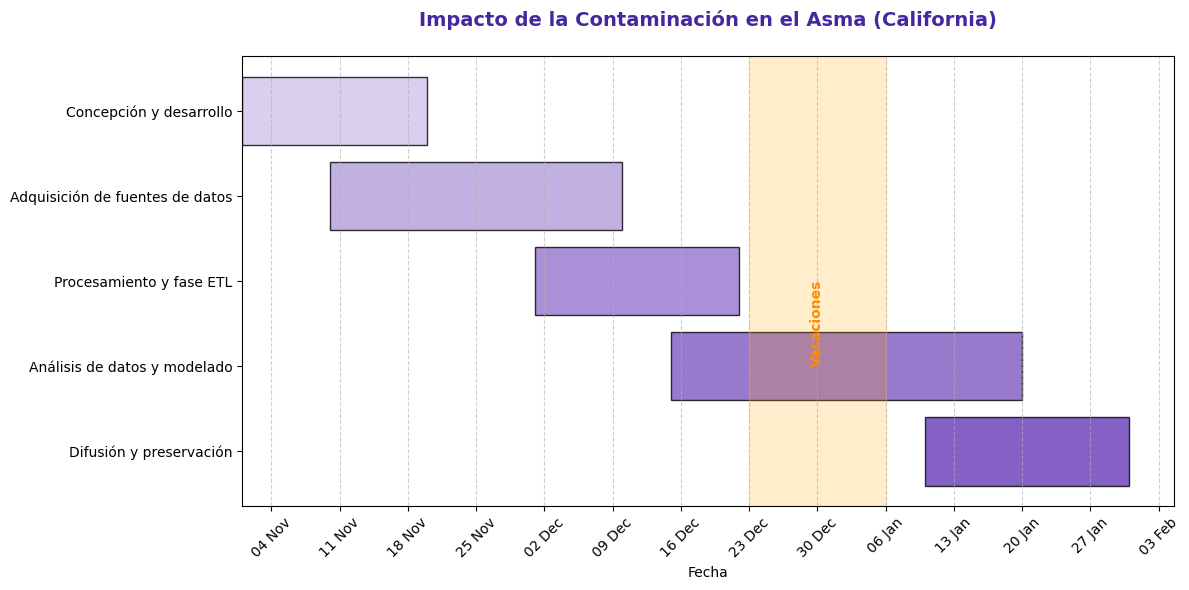

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
from datetime import datetime

# Define the data for the Gantt chart
tasks = [
    dict(Task="Concepción y desarrollo", Start='2025-11-01', Finish='2025-11-20', Resource='WP1'),
    dict(Task="Adquisición de fuentes de datos", Start='2025-11-10', Finish='2025-12-10', Resource='WP2'),
    dict(Task="Procesamiento y fase ETL", Start='2025-12-01', Finish='2025-12-22', Resource='WP3'),
    dict(Task="Análisis de datos y modelado", Start='2025-12-15', Finish='2026-01-20', Resource='WP4'),
    dict(Task="Difusión y preservación", Start='2026-01-10', Finish='2026-01-31', Resource='WP5'),
]

df = pd.DataFrame(tasks)
df['Start'] = pd.to_datetime(df['Start'])
df['Finish'] = pd.to_datetime(df['Finish'])

# Set up colors (Purple theme for Grupo Morado)
colors = {'WP1': '#d1c4e9', 'WP2': '#b39ddb', 'WP3': '#9575cd', 'WP4': '#7e57c2', 'WP5': '#673ab7'}

fig, ax = plt.subplots(figsize=(12, 6))

# Plot bars
for i, task in df.iterrows():
    start_date = mdates.date2num(task['Start'])
    finish_date = mdates.date2num(task['Finish'])
    ax.barh(task['Task'], finish_date - start_date, left=start_date, color=colors[task['Resource']], edgecolor='black', alpha=0.8)

# Add "Vacaciones" shaded area
vac_start = mdates.date2num(datetime(2025, 12, 23))
vac_end = mdates.date2num(datetime(2026, 1, 6))
ax.axvspan(vac_start, vac_end, color='orange', alpha=0.2, label='Vacaciones')
ax.text((vac_start + vac_end) / 2, len(df) / 2, 'Vacaciones', rotation=90, verticalalignment='center', horizontalalignment='center', fontweight='bold', color='darkorange')

# Formatting
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
plt.xticks(rotation=45)

ax.set_xlabel('Fecha')
ax.set_title('Impacto de la Contaminación en el Asma (California)\n', fontsize=14, fontweight='bold', color='#4527a0')
ax.invert_yaxis()  # Tasks from top to bottom
ax.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('diagrama_gantt_asma_california.png')
print("Diagram saved as diagrama_gantt_asma_california.png")